In [1]:
import sys
sys.path.insert(0, '..')

from utils.evaluation import (
    load_and_evaluate_cnnlstm_model
)
from utils.preprocessing import (
    load_cicids2017_data,
    load_ciciot2023_data,
)
import pandas as pd

In [2]:
# =========================
# Config: Define datasets
# =========================
df_cicids2017 = load_cicids2017_data()
df_ciciot2023 = load_ciciot2023_data()

In [12]:
FEATURES = [
    "proto",
    "service",
    "duration",
    "orig_bytes",
    "resp_bytes",
    "conn_state",
    "missed_bytes",
    "history",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
    "orig_pkt_rate",
    "orig_byte_rate",
    "pkt_asymmetry",
    "byte_asymmetry",
    "time_elapsed",
    "flood_rate",
]
TARGET_LABELS = ["BENIGN", "DOS_HTTP_FLOOD", "PORTSCAN"]

In [13]:
label_column = "label"
def split_features_and_target(df):
    X = df[FEATURES].copy()
    y_df = df[df[label_column].isin(TARGET_LABELS)]
    y = y_df[label_column]
    return X, y

X_cicids, y_cicids = split_features_and_target(df_cicids2017)
X_ciciot, y_ciciot = split_features_and_target(df_ciciot2023)

In [ ]:
# Load CICIoT2023 model and evaluate on CICIDS2017
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNN-LSTM with DOS_HTTP_FLOOD properties tested on CICIDS2017"
)

Evaluation for CICIoT2023-trained CNN-LSTM with DOS_HTTP_FLOOD + PORTSCAN properties tested on CICIDS2017:

=== CICIoT2023-trained CNN-LSTM with DOS_HTTP_FLOOD + PORTSCAN properties tested on CICIDS2017 Classification Report ===



ValueError: Found input variables with inconsistent numbers of samples: [933833, 1056715]

Evaluation for CICIDS2017-trained CNNLSTM tested on CICIoT2023:

=== CICIDS2017-trained CNNLSTM tested on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.2013    0.9692    0.3334    342255
DOS_HTTP_FLOOD     0.9480    0.1276    0.2250   1508589

      accuracy                         0.2833   1850844
     macro avg     0.5747    0.5484    0.2792   1850844
  weighted avg     0.8099    0.2833    0.2450   1850844


=== Per-Label Accuracy ===

BENIGN: 0.9692
DOS_HTTP_FLOOD: 0.1276


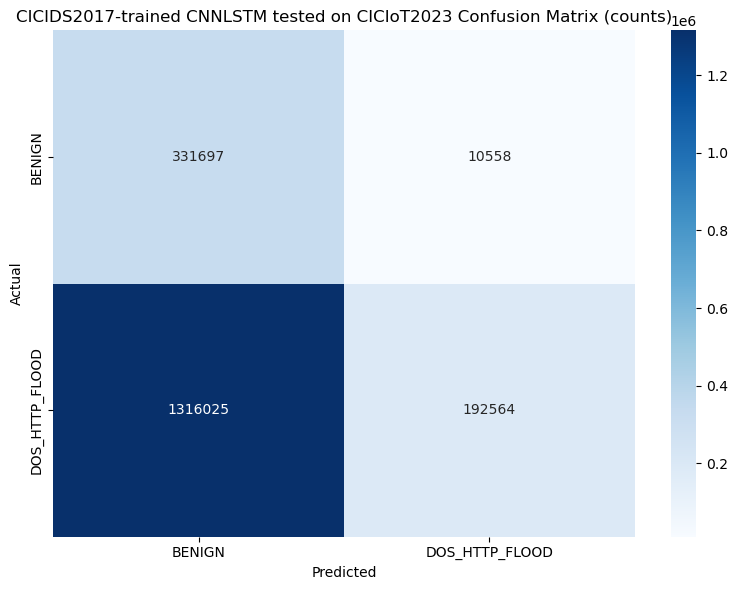

Cross-dataset evaluation saved to: ..\experiments\20260405_210240_2props\cross_eval_on_ciciot2023.json


WindowsPath('../experiments/20260405_210240_2props/cross_eval_on_ciciot2023.json')

In [ ]:
# Load CICIDS2017 model and evaluate on CICIoT2023
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained CNN-LSTM with DOS_HTTP_FLOOD properties tested on CICIoT2023"
)